In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1024.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1825.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/326.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/961.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1132.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/149.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1709.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio/1889.mp3
/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_aud

In [4]:
import torch
import torchaudio
import pandas as pd
import numpy as np
import os
import gc
from sklearn.model_selection import train_test_split

print("torch:", torch.__version__)

# 1. Load Data and Paths
audio_dir = '/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_audio/MEMD_audio'
ann_csv_1 = '/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_Annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv'
ann_csv_2 = '/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music/DEAM_Annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv'

df1 = pd.read_csv(ann_csv_1)
df2 = pd.read_csv(ann_csv_2, usecols=['song_id', ' valence_mean',' valence_std',' arousal_mean',' arousal_std'])
labels_df = pd.concat([df1, df2], ignore_index=True)
labels_df.rename(columns={' valence_mean':'valence_mean',' valence_std':'valence_std',' arousal_mean':'arousal_mean',' arousal_std':'arousal_std'}, inplace=True)

audio_paths = []
for song_id in labels_df['song_id']:
    full_path = os.path.join(audio_dir, f"{song_id}.mp3")
    audio_paths.append(full_path if os.path.exists(full_path) else None)
labels_df['audio_path'] = audio_paths
labels_df = labels_df.dropna(subset=['audio_path'])

# 2. LEAK-FREE SONG-LEVEL SPLIT
song_ids = labels_df['song_id'].values
train_ids, temp_ids = train_test_split(song_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

train_ids_set = set(train_ids)
val_ids_set = set(val_ids)
test_ids_set = set(test_ids)

# 3. COMPUTE TRAIN STATS (No Leakage)
sr = 44100
mel_extractor = torchaudio.transforms.MelSpectrogram(sample_rate=sr)
to_db = torchaudio.transforms.AmplitudeToDB()
fixed_length = 9830

total_sum, total_sq_sum, total_elements = 0.0, 0.0, 0
print("Calculating normalization stats on Training Set...")
for idx, row in labels_df.iterrows():
    if row['song_id'] not in train_ids_set:
        continue
    try:
        waveform, _ = torchaudio.load(row['audio_path'])
        spec_db = to_db(mel_extractor(waveform.mean(dim=0)))
        if spec_db.shape[1] >= fixed_length:
            truncated = spec_db[:, :fixed_length]
            total_sum += truncated.sum().item()
            total_sq_sum += (truncated ** 2).sum().item()
            total_elements += truncated.numel()
    except:
        pass

train_mean = total_sum / total_elements
train_std = np.sqrt((total_sq_sum / total_elements) - (train_mean ** 2))
print(f"Train mean: {train_mean:.4f}, Train std: {train_std:.4f}")

# 4. CHUNK AND SORT INTO MEMORY
chunk_size = 1024
num_chunks = 9

X_train, y_train = [], []
X_val, y_val = [], []
X_test, y_test = [], []

print("Extracting, normalizing, and chunking...")
for idx, row in labels_df.iterrows():
    song_id = row['song_id']
    try:
        waveform, _ = torchaudio.load(row['audio_path'])
        spec_db = to_db(mel_extractor(waveform.mean(dim=0)))
        if spec_db.shape[1] >= fixed_length:
            spec = spec_db[:, :fixed_length]
            spec = (spec - train_mean) / train_std  # Normalize
            spec = spec[:, :9216]  # Truncate
            
            valence = (row['valence_mean'] - 1) / 8
            arousal = (row['arousal_mean'] - 1) / 8
            
            for j in range(num_chunks):
                start = j * chunk_size
                segment = spec[:, start:start + chunk_size].clone()
                
                if song_id in train_ids_set:
                    X_train.append(segment)
                    y_train.append([valence, arousal])
                elif song_id in val_ids_set:
                    X_val.append(segment)
                    y_val.append([valence, arousal])
                elif song_id in test_ids_set:
                    X_test.append(segment)
                    y_test.append([valence, arousal])
    except:
        pass

# 5. SAVE FINAL DATASETS TO DISK
print("Saving pre-chunked datasets to disk...")
os.makedirs('/kaggle/working/processed_data', exist_ok=True)
torch.save({'X': X_train, 'y': y_train}, '/kaggle/working/processed_data/train.pt')
torch.save({'X': X_val, 'y': y_val}, '/kaggle/working/processed_data/val.pt')
torch.save({'X': X_test, 'y': y_test}, '/kaggle/working/processed_data/test.pt')

print("Done! You can now restart the kernel to free up RAM.")

torch: 2.10.0+cu128
Calculating normalization stats on Training Set...


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


Train mean: -33.6747, Train std: 37.4105
Extracting, normalizing, and chunking...
Saving pre-chunked datasets to disk...
Done! You can now restart the kernel to free up RAM.


In [9]:
import torch
import numpy as np
import gc
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch.nn as nn
import torch.optim as optim
from transformers import ASTModel
import torch.cuda.amp as amp

train_data = torch.load('/kaggle/working/processed_data/train.pt', weights_only=True)
val_data = torch.load('/kaggle/working/processed_data/val.pt', weights_only=True)
test_data = torch.load('/kaggle/working/processed_data/test.pt', weights_only=True)

class PreloadedEmotionDataset(Dataset):
    def __init__(self, data_dict):
        self.specs = data_dict['X']
        self.labels = data_dict['y']

    def __len__(self):
        return len(self.specs)

    def __getitem__(self, idx):
        spec = self.specs[idx].float().unsqueeze(0)  # Shape: [1, 128, 1024]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return {"input_values": spec, "labels": label}

batch_size = 16
train_loader = DataLoader(PreloadedEmotionDataset(train_data), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(PreloadedEmotionDataset(val_data), batch_size=batch_size)
test_loader = DataLoader(PreloadedEmotionDataset(test_data), batch_size=batch_size)

# Clear variables
del train_data, val_data, test_data
gc.collect()

23

In [11]:
# AST SETUP
class ASTForEmotionRegression(nn.Module):
    def __init__(self, pretrained='MIT/ast-finetuned-audioset-10-10-0.4593'):
        super().__init__()
        self.ast = ASTModel.from_pretrained(pretrained)
        self.regression_head = nn.Sequential(
            nn.Linear(self.ast.config.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
        
    def forward(self, input_values):
        outputs = self.ast(input_values=input_values.squeeze(1))
        return self.regression_head(outputs.last_hidden_state.mean(dim=1))
        
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ast_model = ASTForEmotionRegression().to(device)
ast_optimizer = optim.Adam(ast_model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
scaler = amp.GradScaler()
num_epochs = 10
for epoch in range(num_epochs):
    ast_model.train()
    running_loss = 0.0
    for batch in train_loader:
        specs, labels = batch["input_values"].to(device), batch["labels"].to(device)
        ast_optimizer.zero_grad()
        
        with amp.autocast():
            loss = criterion(ast_model(specs), labels)
            
        scaler.scale(loss).backward()
        scaler.step(ast_optimizer)
        scaler.update()
        running_loss += loss.item()

    ast_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            specs, labels = batch["input_values"].to(device), batch["labels"].to(device)
            with amp.autocast():
                val_loss += criterion(ast_model(specs), labels).item()
    print(f"AST Epoch {epoch+1}/{num_epochs} | Train Loss: {running_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

# AST EVAL
ast_model.eval()
ast_preds, ast_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        ast_preds.append(ast_model(batch["input_values"].to(device)).cpu())
        ast_labels.append(batch["labels"].cpu())

ast_preds, ast_labels = torch.cat(ast_preds).numpy(), torch.cat(ast_labels).numpy()
print(f"AST MAE (1-9 scale) -> Valence: {mean_absolute_error(ast_labels[:,0], ast_preds[:,0]) * 8:.4f} | Arousal: {mean_absolute_error(ast_labels[:,1], ast_preds[:,1]) * 8:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_58/2607696776.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/tmp/ipykernel_58/2607696776.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_58/2607696776.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead

AST Epoch 1/10 | Train Loss: 0.0243 | Val Loss: 0.0134
AST Epoch 2/10 | Train Loss: 0.0180 | Val Loss: 0.0119
AST Epoch 3/10 | Train Loss: 0.0161 | Val Loss: 0.0118
AST Epoch 4/10 | Train Loss: 0.0151 | Val Loss: 0.0117
AST Epoch 5/10 | Train Loss: 0.0132 | Val Loss: 0.0149
AST Epoch 6/10 | Train Loss: 0.0120 | Val Loss: 0.0130
AST Epoch 7/10 | Train Loss: 0.0104 | Val Loss: 0.0128
AST Epoch 8/10 | Train Loss: 0.0092 | Val Loss: 0.0123
AST Epoch 9/10 | Train Loss: 0.0080 | Val Loss: 0.0132
AST Epoch 10/10 | Train Loss: 0.0073 | Val Loss: 0.0135
AST MAE (1-9 scale) -> Valence: 0.7738 | Arousal: 0.7340


In [12]:
import os

# Create directory for saving checkpoints
os.makedirs('/kaggle/working/saved_models', exist_ok=True)

# Save the state_dict (weights)
ast_weights_path = '/kaggle/working/saved_models/ast_emotion_regression_weights.pth'
torch.save(ast_model.state_dict(), ast_weights_path)

print(f"AST model weights successfully saved to: {ast_weights_path}")

AST model weights successfully saved to: /kaggle/working/saved_models/ast_emotion_regression_weights.pth


In [13]:
# Delete AST model and optimizer from RAM/VRAM
del ast_model, ast_optimizer
gc.collect()
torch.cuda.empty_cache()

print("GPU VRAM cleared. Ready to train CNN.")

GPU VRAM cleared. Ready to train CNN.


In [14]:
# 1. Define CNN Architecture
class CNNForEmotionRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 16 * 128, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# 2. Instantiate and Train CNN
cnn_model = CNNForEmotionRegression().to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

num_epochs = 10
for epoch in range(num_epochs):
    cnn_model.train()
    running_loss = 0.0

    for batch in train_loader:
        specs = batch["input_values"].to(device)
        labels = batch["labels"].to(device)

        cnn_optimizer.zero_grad()
        outputs = cnn_model(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        cnn_optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Validation
    cnn_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            specs = batch["input_values"].to(device)
            labels = batch["labels"].to(device)
            outputs = cnn_model(specs)
            val_loss += criterion(outputs, labels).item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"CNN Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

CNN Epoch 1/10 | Train Loss: 0.0440 | Val Loss: 0.0170
CNN Epoch 2/10 | Train Loss: 0.0282 | Val Loss: 0.0181
CNN Epoch 3/10 | Train Loss: 0.0255 | Val Loss: 0.0140
CNN Epoch 4/10 | Train Loss: 0.0231 | Val Loss: 0.0151
CNN Epoch 5/10 | Train Loss: 0.0216 | Val Loss: 0.0143
CNN Epoch 6/10 | Train Loss: 0.0193 | Val Loss: 0.0136
CNN Epoch 7/10 | Train Loss: 0.0175 | Val Loss: 0.0135
CNN Epoch 8/10 | Train Loss: 0.0157 | Val Loss: 0.0136
CNN Epoch 9/10 | Train Loss: 0.0147 | Val Loss: 0.0135
CNN Epoch 10/10 | Train Loss: 0.0134 | Val Loss: 0.0136


In [15]:
# 1. Evaluate CNN
cnn_model.eval()
cnn_preds, cnn_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["input_values"].to(device)
        targets = batch["labels"].to(device)
        outputs = cnn_model(inputs)
        cnn_preds.append(outputs.cpu())
        cnn_labels.append(targets.cpu())

cnn_preds = torch.cat(cnn_preds).numpy()
cnn_labels = torch.cat(cnn_labels).numpy()

cnn_valence_mae = mean_absolute_error(cnn_labels[:, 0], cnn_preds[:, 0])
cnn_arousal_mae = mean_absolute_error(cnn_labels[:, 1], cnn_preds[:, 1])

print(f"CNN MAE (Normalized 0-1) -> Valence: {cnn_valence_mae:.4f} | Arousal: {cnn_arousal_mae:.4f}")
print(f"CNN MAE (Original 1-9)   -> Valence: {cnn_valence_mae * 8:.4f} | Arousal: {cnn_arousal_mae * 8:.4f}")

# 2. Save CNN Model Weights
cnn_weights_path = '/kaggle/working/saved_models/cnn_emotion_regression_weights.pth'
torch.save(cnn_model.state_dict(), cnn_weights_path)
print(f"CNN model weights saved to: {cnn_weights_path}")

CNN MAE (Normalized 0-1) -> Valence: 0.0995 | Arousal: 0.0989
CNN MAE (Original 1-9)   -> Valence: 0.7959 | Arousal: 0.7915
CNN model weights saved to: /kaggle/working/saved_models/cnn_emotion_regression_weights.pth


In [17]:
!ls /kaggle

input  lib  working


In [18]:
# Purge any previous models from VRAM before initializing LSTM
import gc
torch.cuda.empty_cache()
gc.collect()

# Define the LSTM baseline
class LSTMForEmotionRegression(nn.Module):
    def __init__(self):
        super().__init__()
        # Bidirectional LSTM to process the 1024-frame sequence
        self.lstm = nn.LSTM(
            input_size=128, 
            hidden_size=256, 
            num_layers=2, 
            batch_first=True, 
            bidirectional=True
        )
        
        # 256 hidden_size * 2 (bidirectional) = 512
        self.fc1 = nn.Linear(512, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        # Reshape [B, 1, 128, 1024] -> [B, 1024, 128] for LSTM (Batch, Seq_Len, Features)
        x = x.squeeze(1).permute(0, 2, 1) 
        
        lstm_out, _ = self.lstm(x)
        
        # Mean pooling across the entire 1024-frame sequence
        pooled = lstm_out.mean(dim=1)
        
        x = self.relu(self.fc1(pooled))
        x = self.dropout(x)
        output = self.fc2(x)
        return output

lstm_model = LSTMForEmotionRegression().to(device)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=1e-4)

In [19]:
import torch.amp as amp

scaler = amp.GradScaler('cuda')

for epoch in range(num_epochs):
    lstm_model.train()
    running_loss = 0.0

    for batch in train_loader:
        specs = batch["input_values"].to(device)
        labels = batch["labels"].to(device)

        lstm_optimizer.zero_grad()
        
        # Forward pass with mixed precision
        with amp.autocast('cuda'):
            outputs = lstm_model(specs)
            loss = criterion(outputs, labels)
            
        # Backward pass with scaled gradients
        scaler.scale(loss).backward()
        scaler.step(lstm_optimizer)
        scaler.update()
        
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    lstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            specs = batch["input_values"].to(device)
            labels = batch["labels"].to(device)
            
            with amp.autocast('cuda'):
                outputs = lstm_model(specs)
                batch_loss = criterion(outputs, labels)
            val_loss += batch_loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"LSTM Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

LSTM Epoch 1/10 | Train Loss: 0.0219 | Val Loss: 0.0152
LSTM Epoch 2/10 | Train Loss: 0.0180 | Val Loss: 0.0156
LSTM Epoch 3/10 | Train Loss: 0.0171 | Val Loss: 0.0150
LSTM Epoch 4/10 | Train Loss: 0.0167 | Val Loss: 0.0146
LSTM Epoch 5/10 | Train Loss: 0.0157 | Val Loss: 0.0146
LSTM Epoch 6/10 | Train Loss: 0.0146 | Val Loss: 0.0136
LSTM Epoch 7/10 | Train Loss: 0.0142 | Val Loss: 0.0136
LSTM Epoch 8/10 | Train Loss: 0.0135 | Val Loss: 0.0129
LSTM Epoch 9/10 | Train Loss: 0.0131 | Val Loss: 0.0135
LSTM Epoch 10/10 | Train Loss: 0.0127 | Val Loss: 0.0128


In [20]:
lstm_model.eval()
lstm_preds = []
lstm_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["input_values"].to(device)
        targets = batch["labels"].to(device)
        
        outputs = lstm_model(inputs)
        
        lstm_preds.append(outputs.cpu())
        lstm_labels.append(targets.cpu())

lstm_preds = torch.cat(lstm_preds).numpy()
lstm_labels = torch.cat(lstm_labels).numpy()

from sklearn.metrics import mean_absolute_error
lstm_valence_mae = mean_absolute_error(lstm_labels[:, 0], lstm_preds[:, 0])
lstm_arousal_mae = mean_absolute_error(lstm_labels[:, 1], lstm_preds[:, 1])

print(f"LSTM MAE (Normalized 0-1) -> Valence: {lstm_valence_mae:.4f} | Arousal: {lstm_arousal_mae:.4f}")
print(f"LSTM MAE (Original 1-9)   -> Valence: {lstm_valence_mae * 8:.4f} | Arousal: {lstm_arousal_mae * 8:.4f}")

# Save LSTM Weights
import os
os.makedirs('/kaggle/working/saved_models', exist_ok=True)
lstm_weights_path = '/kaggle/working/saved_models/lstm_emotion_regression_weights.pth'
torch.save(lstm_model.state_dict(), lstm_weights_path)
print(f"LSTM model weights saved to: {lstm_weights_path}")

LSTM MAE (Normalized 0-1) -> Valence: 0.0947 | Arousal: 0.0916
LSTM MAE (Original 1-9)   -> Valence: 0.7579 | Arousal: 0.7325
LSTM model weights saved to: /kaggle/working/saved_models/lstm_emotion_regression_weights.pth


In [21]:
print("\n--- STARTING DUMMY REGRESSOR BASELINE ---")

# 1. Calculate the mean emotion scores strictly from the Training Set
total_valence = 0.0
total_arousal = 0.0
num_samples = 0

for batch in train_loader:
    labels = batch["labels"]
    total_valence += labels[:, 0].sum().item()
    total_arousal += labels[:, 1].sum().item()
    num_samples += labels.size(0)

mean_valence = total_valence / num_samples
mean_arousal = total_arousal / num_samples

print(f"Training Baseline Guesses -> Valence: {mean_valence:.4f}, Arousal: {mean_arousal:.4f}")

# 2. Evaluate guessing the exact same mean for every track in the Test Set
dummy_valence_mae = 0.0
dummy_arousal_mae = 0.0
test_samples = 0

for batch in test_loader:
    labels = batch["labels"]
    
    # Calculate the absolute error between the true labels and our mean guesses
    dummy_valence_mae += torch.abs(labels[:, 0] - mean_valence).sum().item()
    dummy_arousal_mae += torch.abs(labels[:, 1] - mean_arousal).sum().item()
    test_samples += labels.size(0)

dummy_valence_mae /= test_samples
dummy_arousal_mae /= test_samples

print(f"Dummy MAE (Normalized 0-1) -> Valence: {dummy_valence_mae:.4f} | Arousal: {dummy_arousal_mae:.4f}")
print(f"Dummy MAE (Original 1-9)   -> Valence: {dummy_valence_mae * 8:.4f} | Arousal: {dummy_arousal_mae * 8:.4f}")


--- STARTING DUMMY REGRESSOR BASELINE ---
Training Baseline Guesses -> Valence: 0.4898, Arousal: 0.4791
Dummy MAE (Normalized 0-1) -> Valence: 0.1230 | Arousal: 0.1319
Dummy MAE (Original 1-9)   -> Valence: 0.9843 | Arousal: 1.0551


In [22]:
print("\n--- STARTING MLP BASELINE ---")

class MLPForEmotionRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        
        # Flatten the 128 (mel bins) x 1024 (frames) into a single 1D vector
        self.fc1 = nn.Linear(128 * 1024, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        output = self.fc3(x)
        return output

mlp_model = MLPForEmotionRegression().to(device)
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=1e-4)


--- STARTING MLP BASELINE ---


In [23]:
import torch.amp as amp

scaler = amp.GradScaler('cuda')

for epoch in range(num_epochs):
    mlp_model.train()
    running_loss = 0.0

    for batch in train_loader:
        specs = batch["input_values"].to(device)
        labels = batch["labels"].to(device)

        mlp_optimizer.zero_grad()
        
        with amp.autocast('cuda'):
            outputs = mlp_model(specs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(mlp_optimizer)
        scaler.update()
        
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Validation
    mlp_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            specs = batch["input_values"].to(device)
            labels = batch["labels"].to(device)
            
            with amp.autocast('cuda'):
                outputs = mlp_model(specs)
                batch_loss = criterion(outputs, labels)
            val_loss += batch_loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"MLP Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

MLP Epoch 1/10 | Train Loss: 0.6228 | Val Loss: 0.0554
MLP Epoch 2/10 | Train Loss: 0.1369 | Val Loss: 0.0688
MLP Epoch 3/10 | Train Loss: 0.1176 | Val Loss: 0.0300
MLP Epoch 4/10 | Train Loss: 0.0629 | Val Loss: 0.0240
MLP Epoch 5/10 | Train Loss: 0.0626 | Val Loss: 0.0222
MLP Epoch 6/10 | Train Loss: 0.0429 | Val Loss: 0.0225
MLP Epoch 7/10 | Train Loss: 0.0323 | Val Loss: 0.0223
MLP Epoch 8/10 | Train Loss: 0.0300 | Val Loss: 0.0223
MLP Epoch 9/10 | Train Loss: 0.0359 | Val Loss: 0.0223
MLP Epoch 10/10 | Train Loss: 0.0281 | Val Loss: 0.0223


In [24]:
from sklearn.metrics import mean_absolute_error
import os

mlp_model.eval()
mlp_preds = []
mlp_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["input_values"].to(device)
        targets = batch["labels"].to(device)
        
        outputs = mlp_model(inputs)
        
        mlp_preds.append(outputs.cpu())
        mlp_labels.append(targets.cpu())

mlp_preds = torch.cat(mlp_preds).numpy()
mlp_labels = torch.cat(mlp_labels).numpy()

mlp_valence_mae = mean_absolute_error(mlp_labels[:, 0], mlp_preds[:, 0])
mlp_arousal_mae = mean_absolute_error(mlp_labels[:, 1], mlp_preds[:, 1])

print(f"MLP MAE (Normalized 0-1) -> Valence: {mlp_valence_mae:.4f} | Arousal: {mlp_arousal_mae:.4f}")
print(f"MLP MAE (Original 1-9)   -> Valence: {mlp_valence_mae * 8:.4f} | Arousal: {mlp_arousal_mae * 8:.4f}")

# Save MLP Weights
os.makedirs('/kaggle/working/saved_models', exist_ok=True)
mlp_weights_path = '/kaggle/working/saved_models/mlp_emotion_regression_weights.pth'
torch.save(mlp_model.state_dict(), mlp_weights_path)
print(f"MLP model weights saved to: {mlp_weights_path}")

# Purge MLP from VRAM before moving onto any other architectures
del mlp_model, mlp_optimizer, mlp_preds, mlp_labels
gc.collect()
torch.cuda.empty_cache()

MLP MAE (Normalized 0-1) -> Valence: 0.1233 | Arousal: 0.1318
MLP MAE (Original 1-9)   -> Valence: 0.9863 | Arousal: 1.0546
MLP model weights saved to: /kaggle/working/saved_models/mlp_emotion_regression_weights.pth


--- Concordance Correlation Coefficient (CCC) ---
AST CCC -> Valence: 0.5986 | Arousal: 0.6756
LSTM CCC -> Valence: 0.5590 | Arousal: 0.6389

--- Statistical Significance (Wilcoxon Test) ---
Valence Error Difference p-value: 9.2396e-02
Arousal Error Difference p-value: 8.1969e-01
Result: The performance difference is NOT statistically significant.


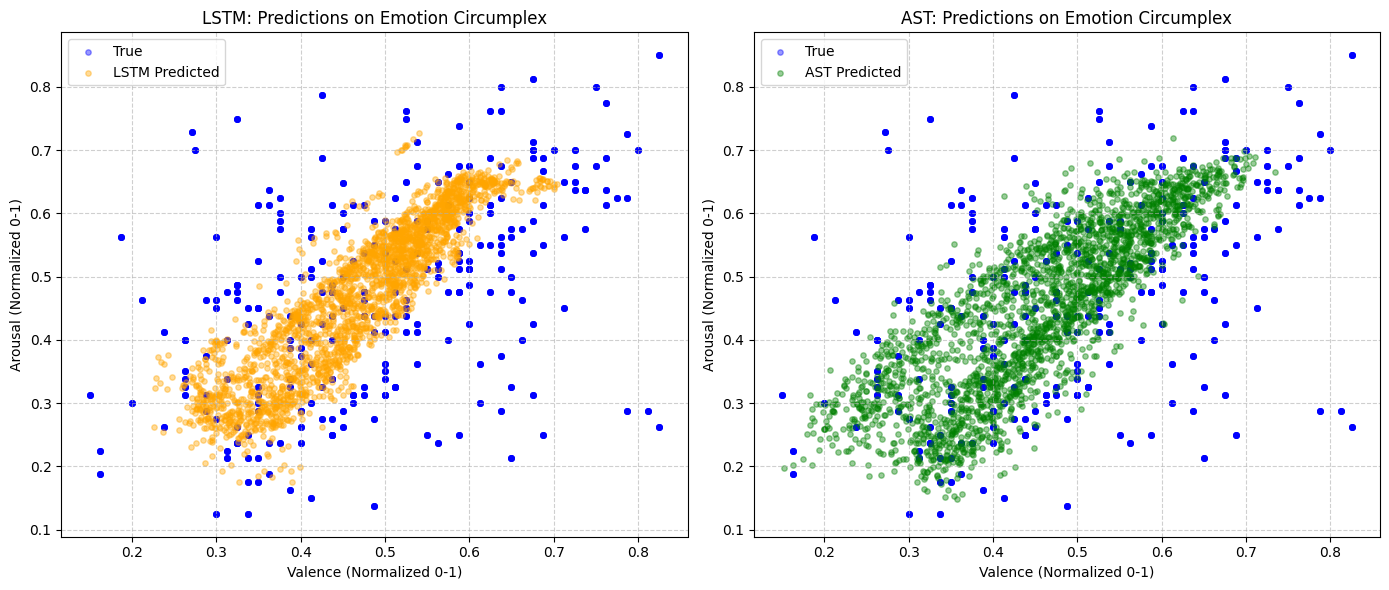

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, wilcoxon

# --- 1. Concordance Correlation Coefficient (CCC) ---
def calculate_ccc(y_true, y_pred):
    """Calculates CCC directly on 1D numpy arrays."""
    mu_x, mu_y = np.mean(y_true), np.mean(y_pred)
    s_x, s_y = np.var(y_true), np.var(y_pred)
    rho, _ = pearsonr(y_true, y_pred)
    ccc = (2.0 * rho * np.sqrt(s_x) * np.sqrt(s_y)) / (s_x + s_y + (mu_x - mu_y)**2)
    return ccc

print("--- Concordance Correlation Coefficient (CCC) ---")
for model_name, preds, labels in [("AST", ast_preds, ast_labels), ("LSTM", lstm_preds, lstm_labels)]:
    val_ccc = calculate_ccc(labels[:, 0], preds[:, 0])
    aro_ccc = calculate_ccc(labels[:, 1], preds[:, 1])
    print(f"{model_name} CCC -> Valence: {val_ccc:.4f} | Arousal: {aro_ccc:.4f}")

# --- 2. Wilcoxon Signed-Rank Test ---
print("\n--- Statistical Significance (Wilcoxon Test) ---")
# Calculate absolute errors for each prediction
ast_val_err = np.abs(ast_labels[:, 0] - ast_preds[:, 0])
lstm_val_err = np.abs(lstm_labels[:, 0] - lstm_preds[:, 0])

ast_aro_err = np.abs(ast_labels[:, 1] - ast_preds[:, 1])
lstm_aro_err = np.abs(lstm_labels[:, 1] - lstm_preds[:, 1])

# Perform paired test on the absolute errors
_, p_val_valence = wilcoxon(ast_val_err, lstm_val_err)
_, p_val_arousal = wilcoxon(ast_aro_err, lstm_aro_err)

print(f"Valence Error Difference p-value: {p_val_valence:.4e}")
print(f"Arousal Error Difference p-value: {p_val_arousal:.4e}")
if p_val_valence < 0.05 and p_val_arousal < 0.05:
    print("Result: The performance difference is STATISTICALLY SIGNIFICANT.")
else:
    print("Result: The performance difference is NOT statistically significant.")

# --- 3. Circumplex Error Visualization ---
plt.figure(figsize=(14, 6))

# LSTM Scatter
plt.subplot(1, 2, 1)
plt.scatter(lstm_labels[:, 0], lstm_labels[:, 1], alpha=0.4, label='True', c='blue', s=15)
plt.scatter(lstm_preds[:, 0], lstm_preds[:, 1], alpha=0.4, label='LSTM Predicted', c='orange', s=15)
plt.title('LSTM: Predictions on Emotion Circumplex')
plt.xlabel('Valence (Normalized 0-1)')
plt.ylabel('Arousal (Normalized 0-1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# AST Scatter
plt.subplot(1, 2, 2)
plt.scatter(ast_labels[:, 0], ast_labels[:, 1], alpha=0.4, label='True', c='blue', s=15)
plt.scatter(ast_preds[:, 0], ast_preds[:, 1], alpha=0.4, label='AST Predicted', c='green', s=15)
plt.title('AST: Predictions on Emotion Circumplex')
plt.xlabel('Valence (Normalized 0-1)')
plt.ylabel('Arousal (Normalized 0-1)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [30]:
import torch
import numpy as np
from transformers import ASTModel
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. DUMMY PREDS (Static Mean) ---
print("Generating Dummy predictions...")
total_valence = 0.0
total_arousal = 0.0
num_samples = 0
for batch in train_loader:
    labels = batch["labels"]
    total_valence += labels[:, 0].sum().item()
    total_arousal += labels[:, 1].sum().item()
    num_samples += labels.size(0)

mean_valence = total_valence / num_samples
mean_arousal = total_arousal / num_samples

dummy_preds_list, true_labels_list = [], []
for batch in test_loader:
    labels = batch["labels"]
    dummy_preds_list.append(torch.tensor([[mean_valence, mean_arousal]] * labels.size(0)))
    true_labels_list.append(labels)

dummy_preds = torch.cat(dummy_preds_list).numpy()
ast_labels = torch.cat(true_labels_list).numpy() # Ground truth baseline

# --- 2. MLP PREDS ---
print("Evaluating MLP...")
class MLPForEmotionRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 1024, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 2)
    def forward(self, x):
        return self.fc3(self.dropout(self.relu(self.fc2(self.dropout(self.relu(self.fc1(self.flatten(x))))))))

mlp_model = MLPForEmotionRegression().to(device)
mlp_model.load_state_dict(torch.load('/kaggle/working/saved_models/mlp_emotion_regression_weights.pth', weights_only=True))
mlp_model.eval()

mlp_preds_list = []
with torch.no_grad():
    for batch in test_loader:
        mlp_preds_list.append(mlp_model(batch["input_values"].to(device)).cpu())
mlp_preds = torch.cat(mlp_preds_list).numpy()
del mlp_model

# --- 3. CNN PREDS---
print("Evaluating CNN...")
class CNNForEmotionRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.flatten = nn.Flatten()
        # Corrected matching linear size for 128x1024 input downsampled 3 times
        self.fc1 = nn.Linear(128 * 16 * 128, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

cnn_model = CNNForEmotionRegression().to(device)
cnn_model.load_state_dict(torch.load('/kaggle/working/saved_models/cnn_emotion_regression_weights.pth', weights_only=True))
cnn_model.eval()

cnn_preds_list = []
with torch.no_grad():
    for batch in test_loader:
        cnn_preds_list.append(cnn_model(batch["input_values"].to(device)).cpu())
cnn_preds = torch.cat(cnn_preds_list).numpy()
del cnn_model
# --- 4. LSTM PREDS ---
print("Evaluating LSTM...")
class LSTMForEmotionRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=128, hidden_size=256, num_layers=2, batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(512, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 2)
    def forward(self, x):
        x = x.squeeze(1).permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        return self.fc2(self.dropout(self.relu(self.fc1(lstm_out.mean(dim=1)))))

lstm_model = LSTMForEmotionRegression().to(device)
lstm_model.load_state_dict(torch.load('/kaggle/working/saved_models/lstm_emotion_regression_weights.pth', weights_only=True))
lstm_model.eval()

lstm_preds_list = []
with torch.no_grad():
    for batch in test_loader:
        lstm_preds_list.append(lstm_model(batch["input_values"].to(device)).cpu())
lstm_preds = torch.cat(lstm_preds_list).numpy()
del lstm_model

# --- 5. AST PREDS ---
print("Evaluating AST...")
class ASTForEmotionRegression(nn.Module):
    def __init__(self, pretrained='MIT/ast-finetuned-audioset-10-10-0.4593'):
        super().__init__()
        self.ast = ASTModel.from_pretrained(pretrained)
        self.regression_head = nn.Sequential(
            nn.Linear(self.ast.config.hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
    def forward(self, input_values):
        outputs = self.ast(input_values=input_values.squeeze(1))
        return self.regression_head(outputs.last_hidden_state.mean(dim=1))

ast_model = ASTForEmotionRegression().to(device)
ast_model.load_state_dict(torch.load('/kaggle/working/saved_models/ast_emotion_regression_weights.pth', weights_only=True))
ast_model.eval()

ast_preds_list = []
with torch.no_grad():
    for batch in test_loader:
        ast_preds_list.append(ast_model(batch["input_values"].to(device)).cpu())
ast_preds = torch.cat(ast_preds_list).numpy()
del ast_model

print("All prediction arrays successfully restored. You can now run the unified evaluation block!")

Generating Dummy predictions...
Evaluating MLP...
Evaluating CNN...
Evaluating LSTM...
Evaluating AST...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All prediction arrays successfully restored. You can now run the unified evaluation block!


Saving final evaluation results to:
/kaggle/output/final_metrics
Prediction sanity checks passed.
Evaluation samples: 2430


FINAL MODEL COMPARISON


/tmp/ipykernel_58/867324282.py:43: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(y_true, y_pred)[0]
/tmp/ipykernel_58/867324282.py:43: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(y_true, y_pred)[0]


,Model,Valence_MAE_1_9,Arousal_MAE_1_9,Valence_CCC,Arousal_CCC,Valence_R2,Arousal_R2,Overall_MAE_0_1,Overall_MSE_0_1
0,LSTM,0.7579,0.7325,0.5590,0.6389,0.3483,0.4336,0.0931,0.0142
1,AST,0.7738,0.7340,0.5986,0.6756,0.3227,0.4437,0.0942,0.0144
2,CNN,0.7959,0.7915,0.4814,0.5684,0.3049,0.3739,0.0992,0.0155
3,Dummy,0.9843,1.0551,0.0000,0.0000,-0.0029,-0.0015,0.1275,0.0235
4,MLP,0.9863,1.0546,0.0000,0.0006,-0.0130,-0.0016,0.1276,0.0237



Saved metrics CSV:
/kaggle/output/final_metrics/final_metrics.csv

Saved metrics JSON:
/kaggle/output/final_metrics/final_metrics.json

Saved all predictions:
/kaggle/output/final_metrics/all_model_predictions.csv


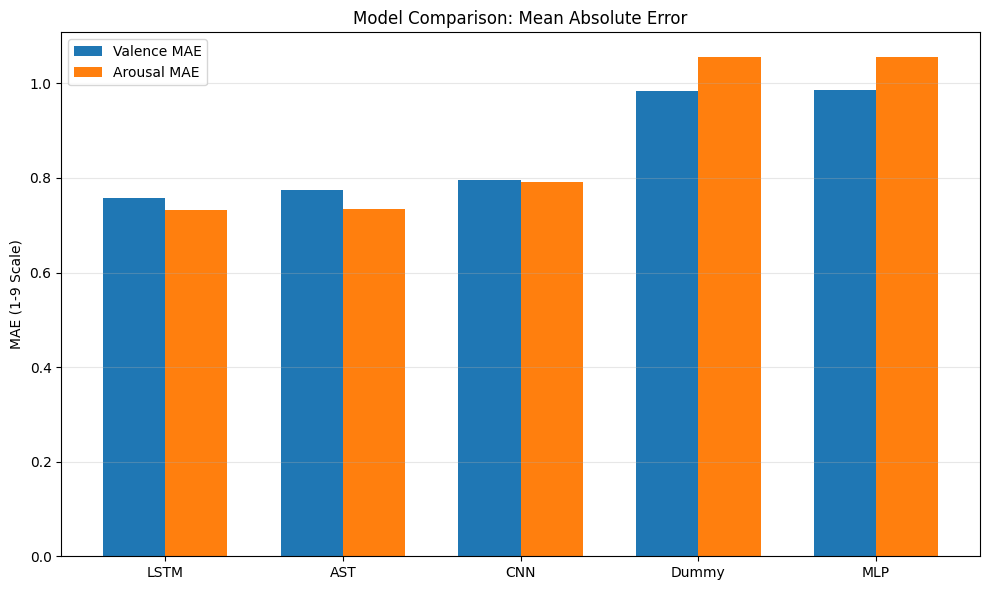

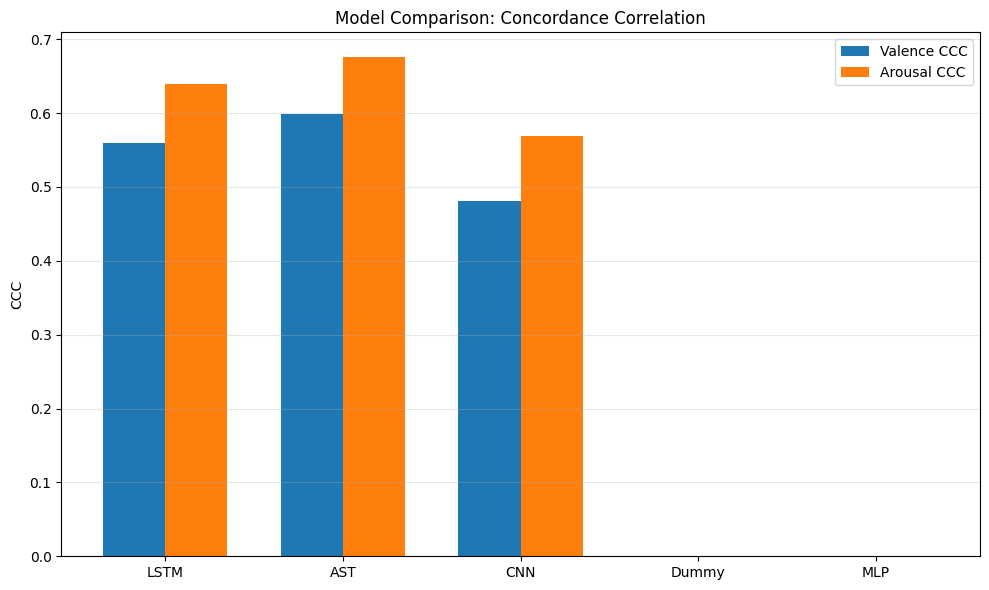

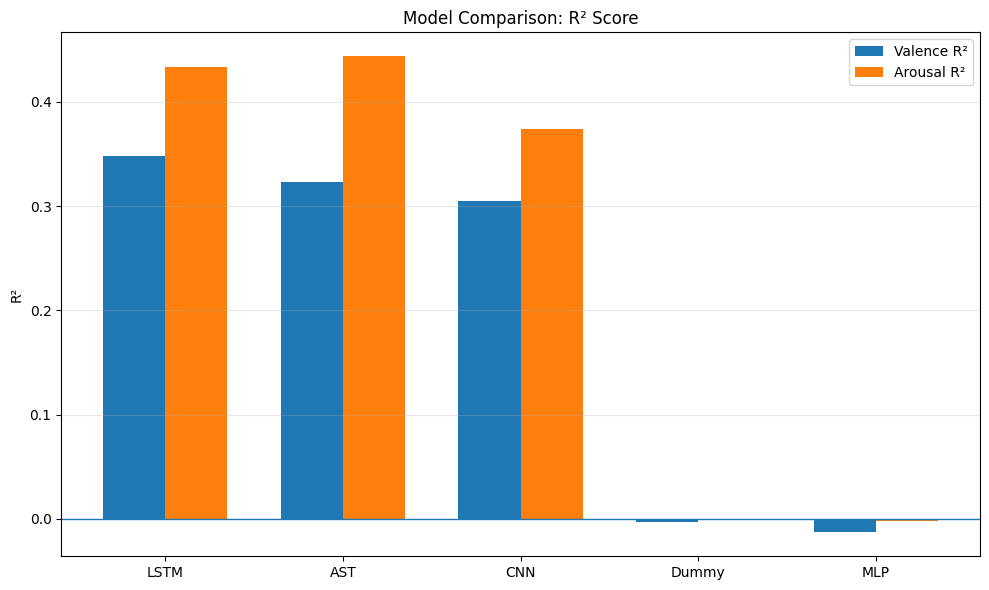

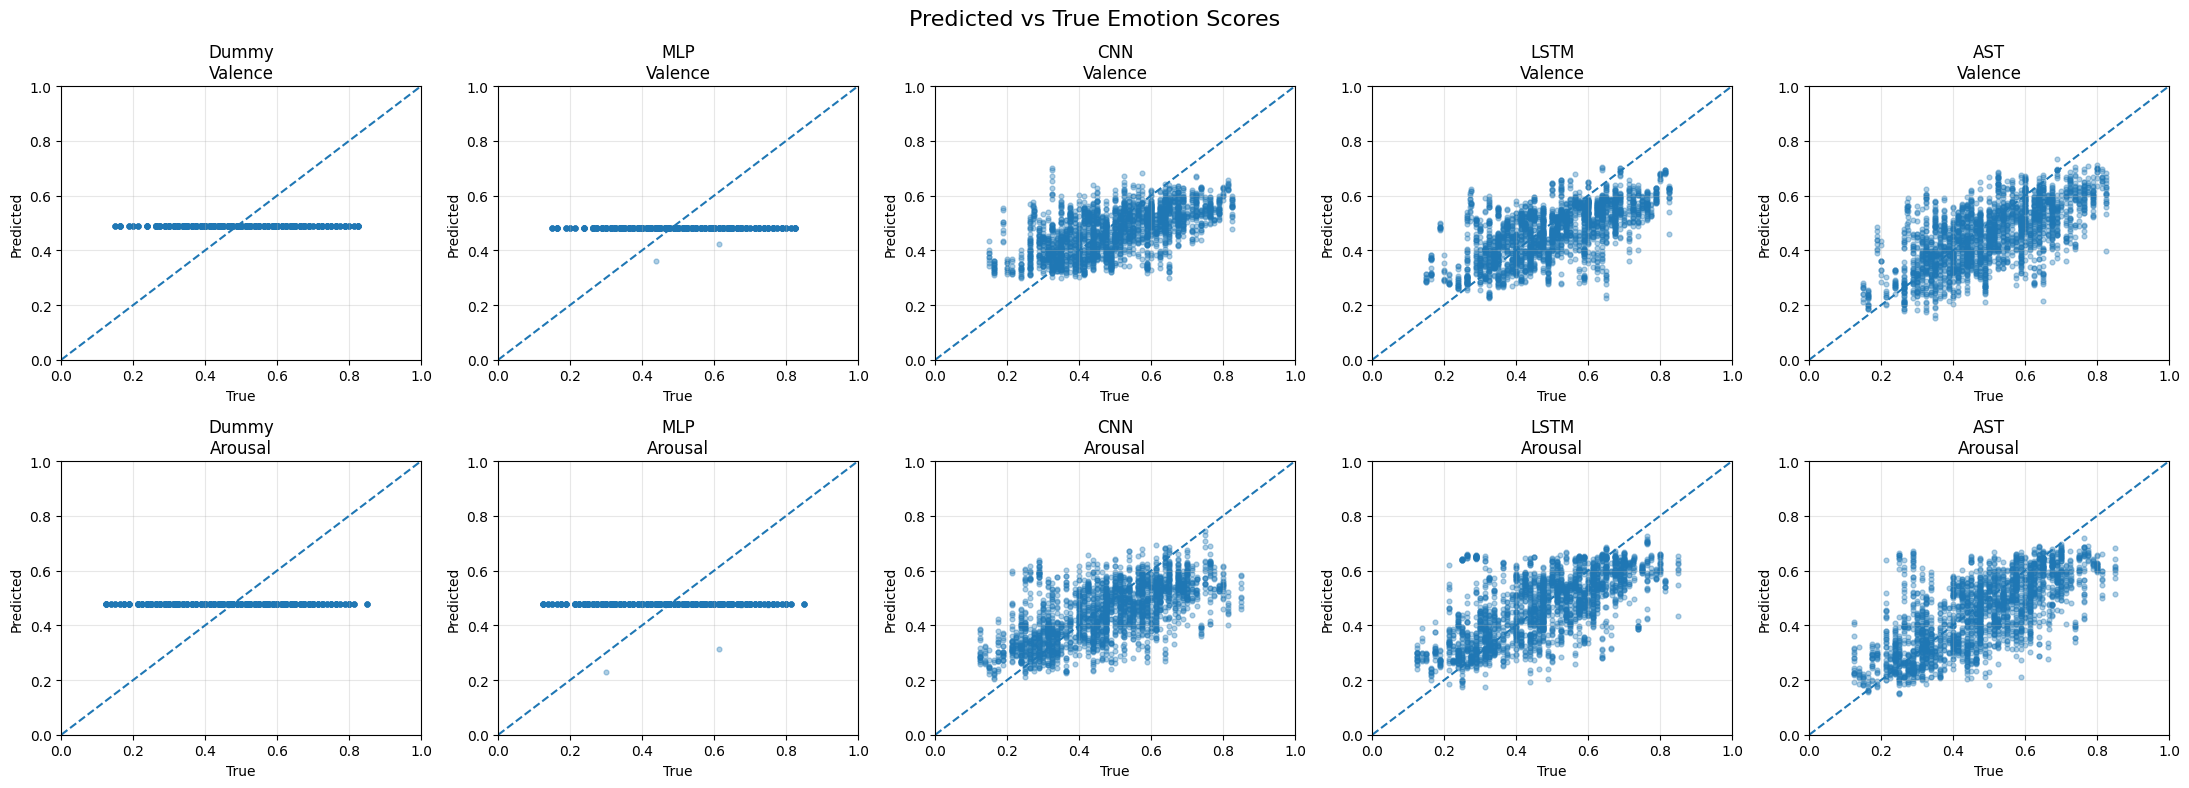

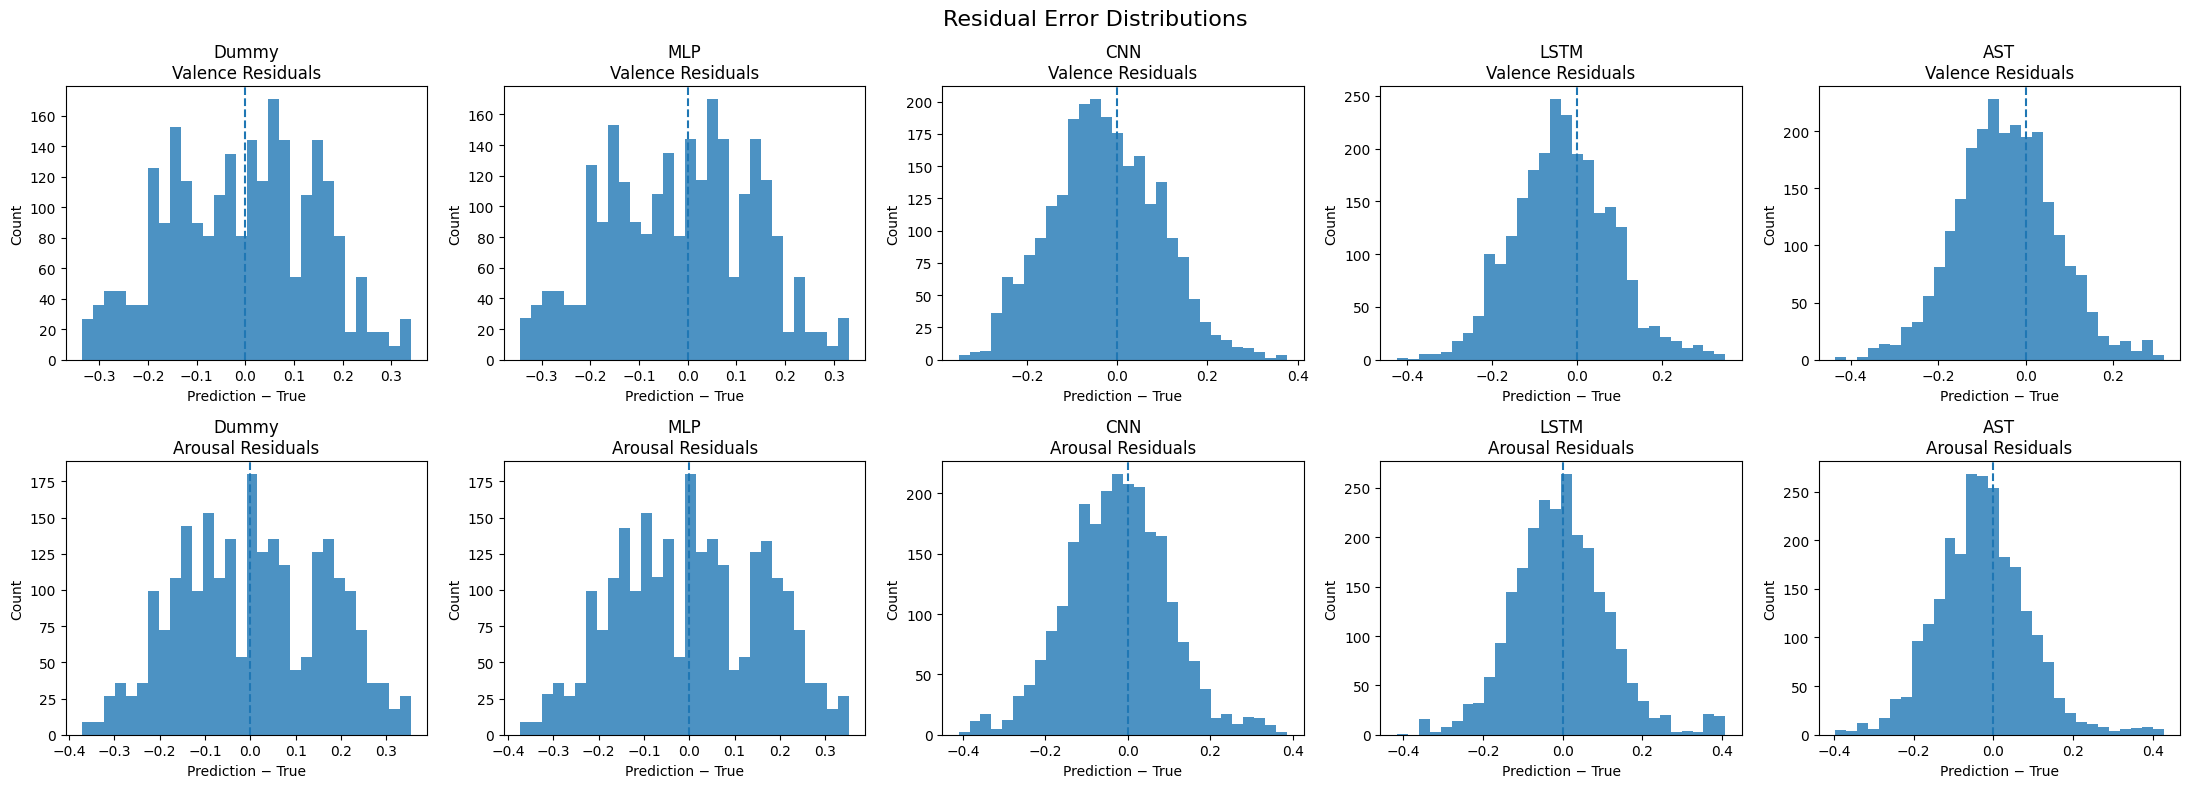

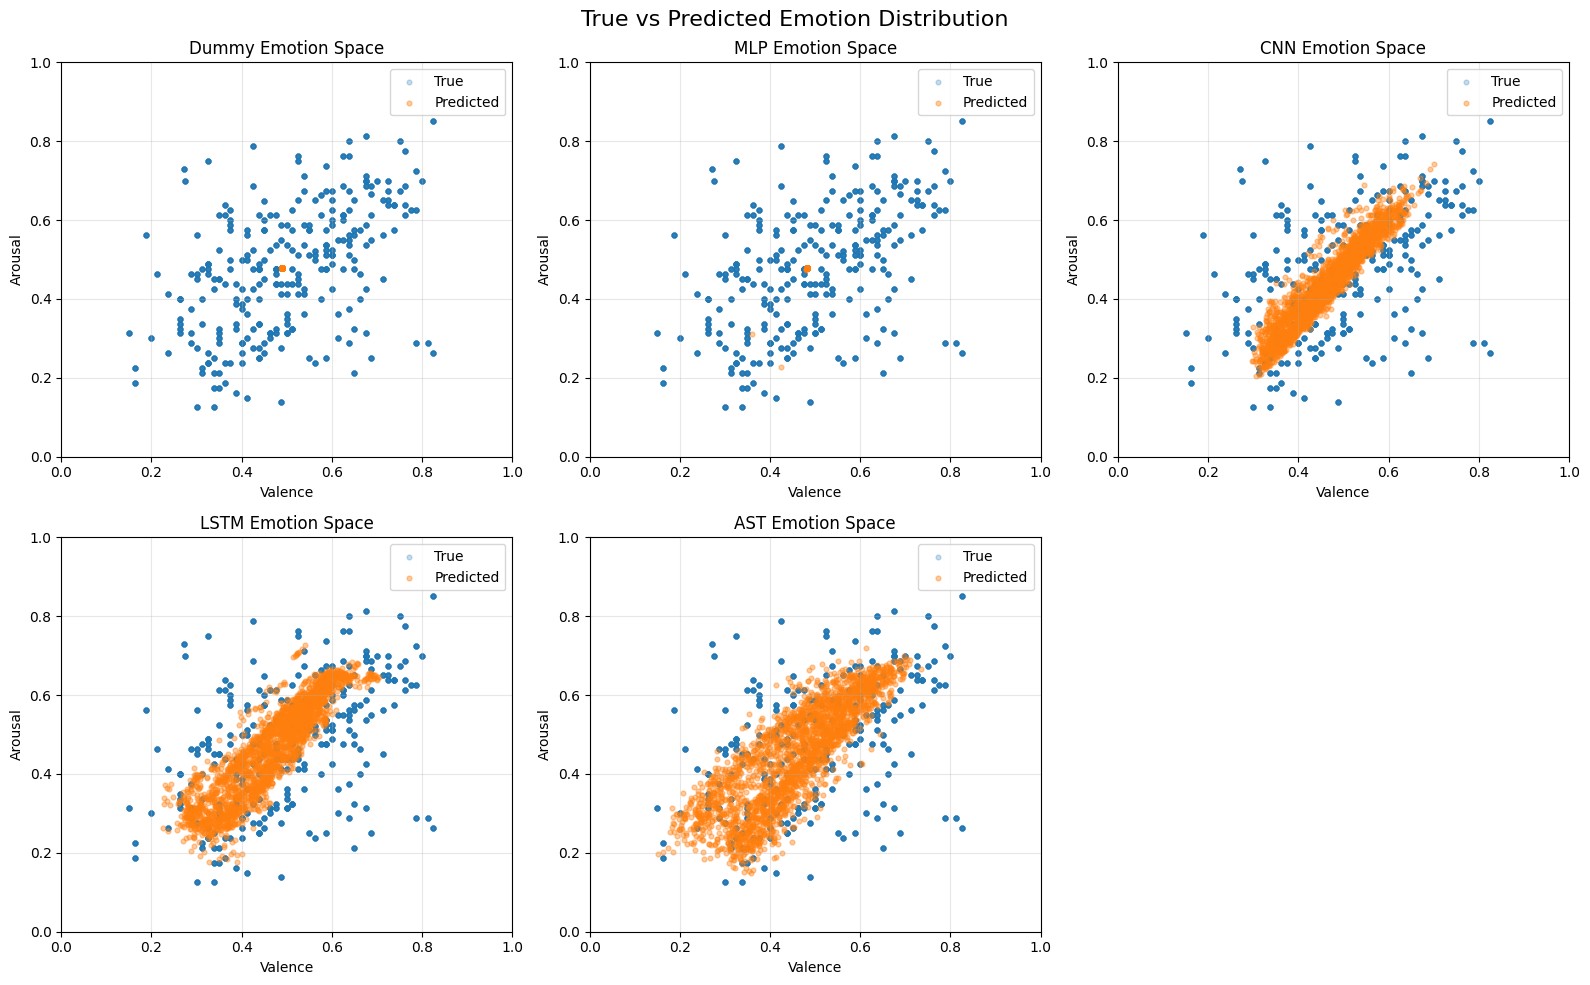

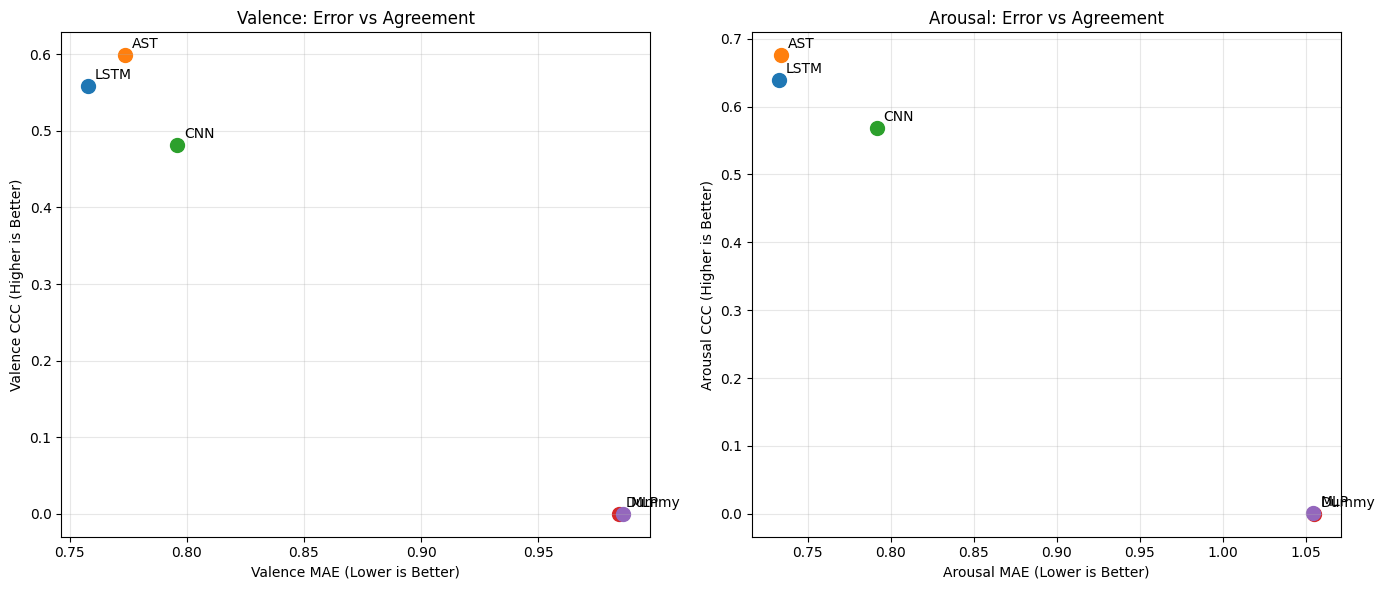



FINAL METRICS EXPORT COMPLETE

Results folder:

/kaggle/output/final_metrics

Generated files:

1. final_metrics.csv
2. final_metrics.json
3. all_model_predictions.csv
4. experiment_info.json

5. mae_comparison.png
6. ccc_comparison.png
7. r2_comparison.png
8. prediction_vs_true.png
9. residual_distributions.png
10. emotion_circumplex_comparison.png
11. mae_vs_ccc.png



In [36]:
# ============================================================
# FINAL METRICS & EVALUATION EXPORT
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

RESULTS_DIR = "/kaggle/output/final_metrics"

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Saving final evaluation results to:\n{RESULTS_DIR}")


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def safe_pearson(y_true, y_pred):
    """
    Pearson correlation.
    Returns NaN if either array is constant.
    """

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan

    return pearsonr(y_true, y_pred)[0]


def calculate_ccc(y_true, y_pred):
    """
    Concordance Correlation Coefficient.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)

    var_true = np.var(y_true)
    var_pred = np.var(y_pred)

    covariance = np.mean(
        (y_true - mean_true) *
        (y_pred - mean_pred)
    )

    denominator = (
        var_true +
        var_pred +
        (mean_true - mean_pred) ** 2
    )

    if denominator == 0:
        return np.nan

    return (
        2 * covariance
    ) / denominator


def compute_metrics(y_true, y_pred):
    """
    Compute all evaluation metrics for one target.
    """

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    pearson = safe_pearson(
        y_true,
        y_pred
    )

    ccc = calculate_ccc(
        y_true,
        y_pred
    )

    errors = y_pred - y_true

    bias = np.mean(errors)

    error_std = np.std(
        errors,
        ddof=1
    )

    return {
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2),
        "Pearson": (
            float(pearson)
            if not np.isnan(pearson)
            else None
        ),
        "CCC": (
            float(ccc)
            if not np.isnan(ccc)
            else None
        ),
        "Bias": float(bias),
        "Error_STD": float(error_std)
    }


# ============================================================
# MODEL PREDICTIONS
# ============================================================

models = {
    "Dummy": dummy_preds,
    "MLP": mlp_preds,
    "CNN": cnn_preds,
    "LSTM": lstm_preds,
    "AST": ast_preds
}

true_labels = ast_labels


# ============================================================
# SANITY CHECK
# ============================================================

for name, preds in models.items():

    assert preds.shape == true_labels.shape, (
        f"{name} predictions have shape {preds.shape}, "
        f"but true labels have shape {true_labels.shape}"
    )

    assert preds.shape[1] == 2, (
        f"{name} must predict "
        "[Valence, Arousal]"
    )


print(
    "Prediction sanity checks passed."
)

print(
    f"Evaluation samples: {len(true_labels)}"
)


# ============================================================
# COMPUTE ALL METRICS
# ============================================================

all_metrics = []

metrics_json = {}

for model_name, preds in models.items():

    # --------------------------------------------------------
    # VALENCE
    # --------------------------------------------------------

    valence_metrics = compute_metrics(
        true_labels[:, 0],
        preds[:, 0]
    )


    # --------------------------------------------------------
    # AROUSAL
    # --------------------------------------------------------

    arousal_metrics = compute_metrics(
        true_labels[:, 1],
        preds[:, 1]
    )


    # --------------------------------------------------------
    # OVERALL
    # --------------------------------------------------------

    overall_mae = mean_absolute_error(
        true_labels,
        preds
    )

    overall_mse = mean_squared_error(
        true_labels,
        preds
    )

    overall_rmse = np.sqrt(
        overall_mse
    )


    # --------------------------------------------------------
    # STORE NORMALIZED METRICS
    # --------------------------------------------------------

    metrics_json[model_name] = {

        "Valence": valence_metrics,

        "Arousal": arousal_metrics,

        "Overall": {

            "MAE": float(overall_mae),

            "MSE": float(overall_mse),

            "RMSE": float(overall_rmse)
        }
    }


    # --------------------------------------------------------
    # DATAFRAME ROW
    # --------------------------------------------------------

    row = {

        "Model": model_name,

        # ============================
        # VALENCE
        # ============================

        "Valence_MAE_0_1":
            valence_metrics["MAE"],

        "Valence_MSE_0_1":
            valence_metrics["MSE"],

        "Valence_RMSE_0_1":
            valence_metrics["RMSE"],

        "Valence_R2":
            valence_metrics["R2"],

        "Valence_Pearson":
            valence_metrics["Pearson"],

        "Valence_CCC":
            valence_metrics["CCC"],

        "Valence_Bias":
            valence_metrics["Bias"],

        "Valence_Error_STD":
            valence_metrics["Error_STD"],


        # ============================
        # AROUSAL
        # ============================

        "Arousal_MAE_0_1":
            arousal_metrics["MAE"],

        "Arousal_MSE_0_1":
            arousal_metrics["MSE"],

        "Arousal_RMSE_0_1":
            arousal_metrics["RMSE"],

        "Arousal_R2":
            arousal_metrics["R2"],

        "Arousal_Pearson":
            arousal_metrics["Pearson"],

        "Arousal_CCC":
            arousal_metrics["CCC"],

        "Arousal_Bias":
            arousal_metrics["Bias"],

        "Arousal_Error_STD":
            arousal_metrics["Error_STD"],


        # ============================
        # OVERALL NORMALIZED
        # ============================

        "Overall_MAE_0_1":
            overall_mae,

        "Overall_MSE_0_1":
            overall_mse,

        "Overall_RMSE_0_1":
            overall_rmse,


        # ============================
        # ORIGINAL DEAM SCALE 1-9
        # ============================

        "Valence_MAE_1_9":
            valence_metrics["MAE"] * 8,

        "Valence_MSE_1_9":
            valence_metrics["MSE"] * 64,

        "Valence_RMSE_1_9":
            valence_metrics["RMSE"] * 8,

        "Arousal_MAE_1_9":
            arousal_metrics["MAE"] * 8,

        "Arousal_MSE_1_9":
            arousal_metrics["MSE"] * 64,

        "Arousal_RMSE_1_9":
            arousal_metrics["RMSE"] * 8,

        "Overall_MAE_1_9":
            overall_mae * 8,

        "Overall_MSE_1_9":
            overall_mse * 64,

        "Overall_RMSE_1_9":
            overall_rmse * 8
    }

    all_metrics.append(row)


# ============================================================
# METRICS DATAFRAME
# ============================================================

metrics_df = pd.DataFrame(
    all_metrics
)

metrics_df = metrics_df.sort_values(
    by="Overall_MAE_0_1",
    ascending=True
).reset_index(drop=True)


print("\n")
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display_columns = [

    "Model",

    "Valence_MAE_1_9",
    "Arousal_MAE_1_9",

    "Valence_CCC",
    "Arousal_CCC",

    "Valence_R2",
    "Arousal_R2",

    "Overall_MAE_0_1",
    "Overall_MSE_0_1"
]

display(
    metrics_df[
        display_columns
    ].round(4)
)


# ============================================================
# SAVE METRICS
# ============================================================

metrics_csv_path = os.path.join(
    RESULTS_DIR,
    "final_metrics.csv"
)

metrics_df.to_csv(
    metrics_csv_path,
    index=False
)


metrics_json_path = os.path.join(
    RESULTS_DIR,
    "final_metrics.json"
)

with open(
    metrics_json_path,
    "w"
) as f:

    json.dump(
        metrics_json,
        f,
        indent=4
    )


print(
    f"\nSaved metrics CSV:\n{metrics_csv_path}"
)

print(
    f"\nSaved metrics JSON:\n{metrics_json_path}"
)


# ============================================================
# SAVE RAW PREDICTIONS
# ============================================================

prediction_data = {

    "True_Valence":
        true_labels[:, 0],

    "True_Arousal":
        true_labels[:, 1]
}


for model_name, preds in models.items():

    prediction_data[
        f"{model_name}_Valence"
    ] = preds[:, 0]

    prediction_data[
        f"{model_name}_Arousal"
    ] = preds[:, 1]


predictions_df = pd.DataFrame(
    prediction_data
)


predictions_path = os.path.join(
    RESULTS_DIR,
    "all_model_predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)


print(
    f"\nSaved all predictions:\n{predictions_path}"
)


# ============================================================
# PLOT 1
# MAE COMPARISON
# ============================================================

names = metrics_df["Model"].tolist()

x = np.arange(
    len(names)
)

width = 0.35


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.bar(
    x - width / 2,
    metrics_df["Valence_MAE_1_9"],
    width,
    label="Valence MAE"
)

ax.bar(
    x + width / 2,
    metrics_df["Arousal_MAE_1_9"],
    width,
    label="Arousal MAE"
)


ax.set_xticks(x)

ax.set_xticklabels(
    names
)

ax.set_ylabel(
    "MAE (1-9 Scale)"
)

ax.set_title(
    "Model Comparison: Mean Absolute Error"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "mae_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 2
# CCC COMPARISON
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.bar(
    x - width / 2,
    metrics_df["Valence_CCC"],
    width,
    label="Valence CCC"
)

ax.bar(
    x + width / 2,
    metrics_df["Arousal_CCC"],
    width,
    label="Arousal CCC"
)


ax.set_xticks(x)

ax.set_xticklabels(
    names
)

ax.set_ylabel(
    "CCC"
)

ax.set_title(
    "Model Comparison: Concordance Correlation"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "ccc_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 3
# R2 COMPARISON
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.bar(
    x - width / 2,
    metrics_df["Valence_R2"],
    width,
    label="Valence R²"
)

ax.bar(
    x + width / 2,
    metrics_df["Arousal_R2"],
    width,
    label="Arousal R²"
)


ax.axhline(
    0,
    linewidth=1
)

ax.set_xticks(x)

ax.set_xticklabels(
    names
)

ax.set_ylabel(
    "R²"
)

ax.set_title(
    "Model Comparison: R² Score"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "r2_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 4
# PREDICTION VS TRUE VALUES
# ============================================================

fig, axes = plt.subplots(
    2,
    len(models),
    figsize=(22, 8)
)


for column, (
    model_name,
    preds
) in enumerate(models.items()):


    # --------------------------------------------------------
    # VALENCE
    # --------------------------------------------------------

    ax = axes[0, column]

    ax.scatter(
        true_labels[:, 0],
        preds[:, 0],
        alpha=0.35,
        s=12
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax.set_title(
        f"{model_name}\nValence"
    )

    ax.set_xlabel(
        "True"
    )

    ax.set_ylabel(
        "Predicted"
    )

    ax.set_xlim(0, 1)

    ax.set_ylim(0, 1)

    ax.grid(
        alpha=0.3
    )


    # --------------------------------------------------------
    # AROUSAL
    # --------------------------------------------------------

    ax = axes[1, column]

    ax.scatter(
        true_labels[:, 1],
        preds[:, 1],
        alpha=0.35,
        s=12
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax.set_title(
        f"{model_name}\nArousal"
    )

    ax.set_xlabel(
        "True"
    )

    ax.set_ylabel(
        "Predicted"
    )

    ax.set_xlim(0, 1)

    ax.set_ylim(0, 1)

    ax.grid(
        alpha=0.3
    )


plt.suptitle(
    "Predicted vs True Emotion Scores",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "prediction_vs_true.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 5
# RESIDUAL DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(
    2,
    len(models),
    figsize=(22, 8)
)


for column, (
    model_name,
    preds
) in enumerate(models.items()):


    valence_residuals = (
        preds[:, 0] -
        true_labels[:, 0]
    )

    arousal_residuals = (
        preds[:, 1] -
        true_labels[:, 1]
    )


    # --------------------------------------------------------
    # VALENCE RESIDUALS
    # --------------------------------------------------------

    ax = axes[0, column]

    ax.hist(
        valence_residuals,
        bins=30,
        alpha=0.8
    )

    ax.axvline(
        0,
        linestyle="--"
    )

    ax.set_title(
        f"{model_name}\nValence Residuals"
    )

    ax.set_xlabel(
        "Prediction − True"
    )

    ax.set_ylabel(
        "Count"
    )


    # --------------------------------------------------------
    # AROUSAL RESIDUALS
    # --------------------------------------------------------

    ax = axes[1, column]

    ax.hist(
        arousal_residuals,
        bins=30,
        alpha=0.8
    )

    ax.axvline(
        0,
        linestyle="--"
    )

    ax.set_title(
        f"{model_name}\nArousal Residuals"
    )

    ax.set_xlabel(
        "Prediction − True"
    )

    ax.set_ylabel(
        "Count"
    )


plt.suptitle(
    "Residual Error Distributions",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "residual_distributions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 6
# EMOTION CIRCUMPLEX
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 10)
)

axes = axes.flatten()


for index, (
    model_name,
    preds
) in enumerate(models.items()):

    ax = axes[index]

    ax.scatter(
        true_labels[:, 0],
        true_labels[:, 1],
        alpha=0.25,
        s=12,
        label="True"
    )

    ax.scatter(
        preds[:, 0],
        preds[:, 1],
        alpha=0.4,
        s=12,
        label="Predicted"
    )

    ax.set_title(
        f"{model_name} Emotion Space"
    )

    ax.set_xlabel(
        "Valence"
    )

    ax.set_ylabel(
        "Arousal"
    )

    ax.set_xlim(
        0,
        1
    )

    ax.set_ylim(
        0,
        1
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend()


axes[-1].axis(
    "off"
)


plt.suptitle(
    "True vs Predicted Emotion Distribution",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "emotion_circumplex_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PLOT 7
# MAE VS CCC
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)


# ------------------------------------------------------------
# VALENCE
# ------------------------------------------------------------

ax = axes[0]

for _, row in metrics_df.iterrows():

    ax.scatter(
        row["Valence_MAE_1_9"],
        row["Valence_CCC"],
        s=100
    )

    ax.annotate(
        row["Model"],
        (
            row["Valence_MAE_1_9"],
            row["Valence_CCC"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )


ax.set_xlabel(
    "Valence MAE (Lower is Better)"
)

ax.set_ylabel(
    "Valence CCC (Higher is Better)"
)

ax.set_title(
    "Valence: Error vs Agreement"
)

ax.grid(
    alpha=0.3
)


# ------------------------------------------------------------
# AROUSAL
# ------------------------------------------------------------

ax = axes[1]

for _, row in metrics_df.iterrows():

    ax.scatter(
        row["Arousal_MAE_1_9"],
        row["Arousal_CCC"],
        s=100
    )

    ax.annotate(
        row["Model"],
        (
            row["Arousal_MAE_1_9"],
            row["Arousal_CCC"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )


ax.set_xlabel(
    "Arousal MAE (Lower is Better)"
)

ax.set_ylabel(
    "Arousal CCC (Higher is Better)"
)

ax.set_title(
    "Arousal: Error vs Agreement"
)

ax.grid(
    alpha=0.3
)


plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "mae_vs_ccc.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE EXPERIMENT INFORMATION
# ============================================================

experiment_info = {

    "dataset": "DEAM",

    "targets": [
        "Valence",
        "Arousal"
    ],

    "normalized_target_range": [
        0,
        1
    ],

    "original_target_range": [
        1,
        9
    ],

    "models": list(
        models.keys()
    ),

    "evaluation_samples":
        int(len(true_labels)),

    "metrics": [

        "MAE",

        "MSE",

        "RMSE",

        "R2",

        "Pearson",

        "CCC",

        "Bias",

        "Error_STD"
    ]
}


with open(
    os.path.join(
        RESULTS_DIR,
        "experiment_info.json"
    ),
    "w"
) as f:

    json.dump(
        experiment_info,
        f,
        indent=4
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL METRICS EXPORT COMPLETE")
print("=" * 80)

print(
    f"""
Results folder:

{RESULTS_DIR}

Generated files:

1. final_metrics.csv
2. final_metrics.json
3. all_model_predictions.csv
4. experiment_info.json

5. mae_comparison.png
6. ccc_comparison.png
7. r2_comparison.png
8. prediction_vs_true.png
9. residual_distributions.png
10. emotion_circumplex_comparison.png
11. mae_vs_ccc.png
"""
)

In [40]:
import shutil

shutil.make_archive(
    "/kaggle/output/final_metrics",
    "zip",
    "/kaggle/output/final_metrics"
)

print("Created: /kaggle/output/final_metrics.zip")

Created: /kaggle/output/final_metrics.zip


In [39]:
from IPython.display import FileLink

FileLink("/kaggle/working/final_metrics.zip")

/kaggle/working/final_metrics.zip